<a href="https://colab.research.google.com/github/kelvin-yg98/Kelvin-Programming/blob/main/Kelvin%20Individual%20project%20programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.makedirs("data", exist_ok=True)

import time
import requests
import pandas as pd
import os

os.makedirs("data", exist_ok=True)

BASE_URL = "https://pokeapi.co/api/v2"

def fetch_pokemon_detail(name):
    """Fetch full stats for a single Pokémon by name."""
    url = f"{BASE_URL}/pokemon/{name}"
    response = requests.get(url, timeout=10)
    if response.status_code != 200:
        return None

    data = response.json()

    # Flatten the stats list into a dictionary
    stats = {s["stat"]["name"]: s["base_stat"] for s in data["stats"]}

    # Primary type is the first entry in the types list
    types = [t["type"]["name"] for t in data["types"]]
    primary_type = types[0] if types else None

    record = {
        "name":            data["name"],
        "primary_type":    primary_type,
        "hp":              stats.get("hp"),
        "attack":          stats.get("attack"),
        "defense":         stats.get("defense"),
        "sp_attack":       stats.get("special-attack"),
        "sp_defense":      stats.get("special-defense"),
        "speed":           stats.get("speed"),
        "height":          data["height"],
        "weight":          data["weight"],
        "base_experience": data.get("base_experience"),
        "num_abilities":   len(data["abilities"]),
        "num_moves":       len(data["moves"]),
    }
    return record


def fetch_all_records(limit=300):
    """Get a list of Pokémon names then fetch details for each one."""
    list_url = f"{BASE_URL}/pokemon?limit={limit}&offset=0"
    response = requests.get(list_url, timeout=10)
    response.raise_for_status()
    pokemon_list = response.json()["results"]

    records = []
    total = len(pokemon_list)

    for i, poke in enumerate(pokemon_list, start=1):
        # Display progress
        print(f"  [{i}/{total}] {poke['name']}", end="\r")
        detail = fetch_pokemon_detail(poke["name"])
        if detail:
            records.append(detail)
        time.sleep(0.15) # pause to avoid API overload

    print(f"\nFetched {len(records)} Pokémon records.")
    return records


# Run data fetching and save raw data
records = fetch_all_records(limit=300)
df_raw = pd.DataFrame(records)
df_raw.to_csv("data/raw_data.csv", index=False)

print(f"\nSaved {len(df_raw)} rows to data/raw_data.csv")
print("\nType distribution:")
print(df_raw["primary_type"].value_counts())
print("\nFirst 5 rows:")
display(df_raw.head())

STEP 1 — First Look
Rows: 300   Columns: 13

Column data types:
name               object
primary_type       object
hp                  int64
attack              int64
defense             int64
sp_attack           int64
sp_defense          int64
speed               int64
height              int64
weight              int64
base_experience     int64
num_abilities       int64
num_moves           int64
dtype: object

Missing values per column:
name               0
primary_type       0
hp                 0
attack             0
defense            0
sp_attack          0
sp_defense         0
speed              0
height             0
weight             0
base_experience    0
num_abilities      0
num_moves          0
dtype: int64

Duplicate rows: 0

Class distribution (primary_type):
primary_type
water       54
normal      49
bug         32
grass       29
fire        23
psychic     18
poison      15
electric    15
rock        14
fighting    11
ground      11
fairy        7
dark         7
ice    

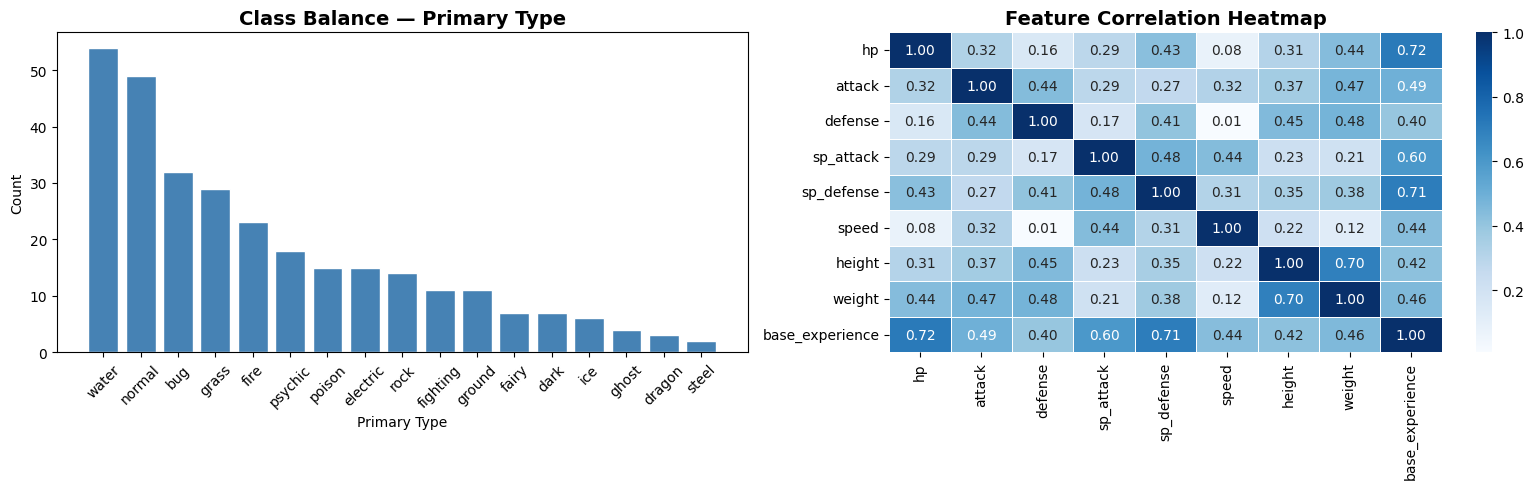

✅ EDA plots saved


<Figure size 1600x500 with 0 Axes>

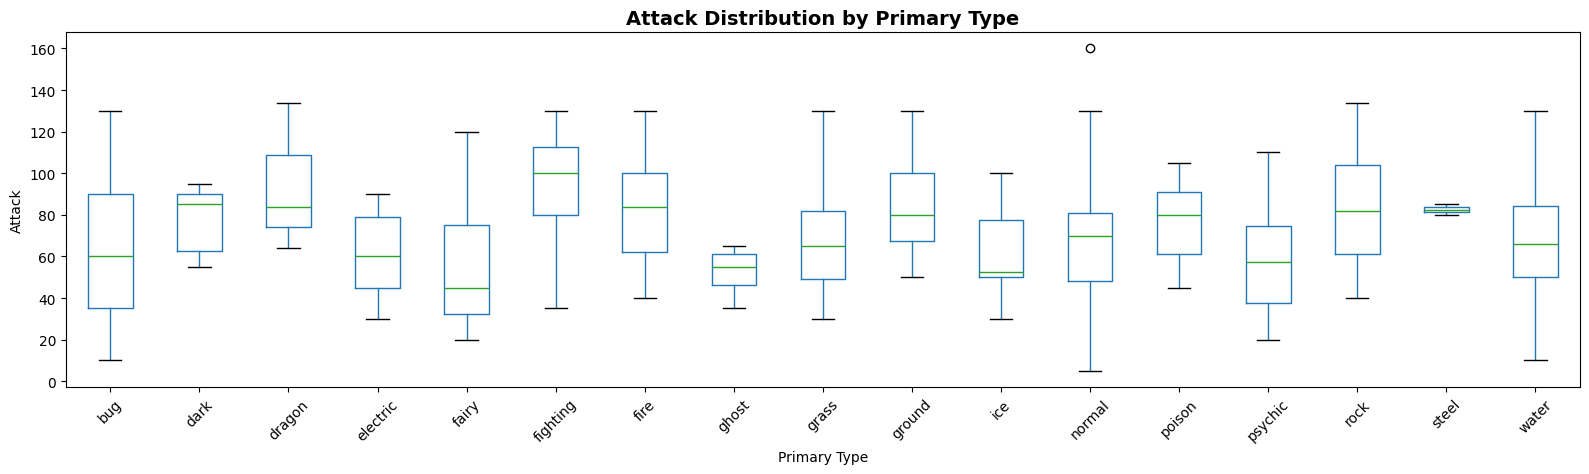

✅ Dropped 0 rows with missing primary_type
✅ Filled 0 missing base_experience values with median (142.0)
✅ Dropped 0 duplicate rows
✅ Merging rare types into 'other': ['ghost', 'dragon', 'steel']

Outlier check (IQR method):
  hp: 7 outlier(s) — kept (likely legendaries, not errors)
  attack: 1 outlier(s) — kept (likely legendaries, not errors)
  defense: 7 outlier(s) — kept (likely legendaries, not errors)
  sp_attack: 1 outlier(s) — kept (likely legendaries, not errors)
  sp_defense: 6 outlier(s) — kept (likely legendaries, not errors)
  speed: 2 outlier(s) — kept (likely legendaries, not errors)
  height: 7 outlier(s) — kept (likely legendaries, not errors)
  weight: 23 outlier(s) — kept (likely legendaries, not errors)
  base_experience: 2 outlier(s) — kept (likely legendaries, not errors)

✅ Saved 300 rows to data/clean_data.csv

Final class distribution:
primary_type
water       54
normal      49
bug         32
grass       29
fire        23
psychic     18
poison      15
electric 

In [ ]:
import pandas as pd
import numpy as np

# Load and initially inspect the data
df = pd.read_csv("data/raw_data.csv")

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("\nClass distribution (primary_type):")
print(df["primary_type"].value_counts())





# Visualize data before cleaning
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Class balance
type_counts = df["primary_type"].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Class Balance — Primary Type", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Primary Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Chart 2: Correlation heatmap for numeric columns
numeric_cols = ["hp","attack","defense","sp_attack","sp_defense",
                "speed","height","weight","base_experience"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("data/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()



# Chart 3: Boxplots of Attack by Type
plt.figure(figsize=(16, 5))
type_order = df.groupby("primary_type")["attack"].median().sort_values(ascending=False).index
df_box = df[df["primary_type"].isin(type_order)]
df_box.boxplot(column="attack", by="primary_type",
               figsize=(16,5), rot=45, grid=False)
plt.title("Attack Distribution by Primary Type", fontsize=14, fontweight="bold")
plt.suptitle("")
plt.xlabel("Primary Type")
plt.ylabel("Attack")
plt.tight_layout()
plt.show()


# Clean the data
df_clean = df.copy()

# Drop rows with missing primary_type (cannot train classifier without label)
before_drop_target = len(df_clean)
df_clean = df_clean.dropna(subset=["primary_type"])
print(f"Dropped {before_drop_target - len(df_clean)} rows with missing primary_type.")

# Fill missing base_experience with the median (robust to outliers)
missing_exp_count = df_clean["base_experience"].isnull().sum()
median_exp_value  = df_clean["base_experience"].median()
df_clean["base_experience"] = df_clean["base_experience"].fillna(median_exp_value)
print(f"Filled {missing_exp_count} missing base_experience values with median ({median_exp_value}).")

# Drop exact duplicate rows
before_drop_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before_drop_duplicates - len(df_clean)} duplicate rows.")

# Merge rare types (fewer than 5 examples) into 'other' to aid stratified splitting
type_counts_clean = df_clean["primary_type"].value_counts()
rare_types_list  = type_counts_clean[type_counts_clean < 5].index.tolist()
if rare_types_list:
    print(f"Merging rare types into 'other': {rare_types_list}")
    df_clean["primary_type"] = df_clean["primary_type"].replace(
        {t: "other" for t in rare_types_list}
    )
else:
    print("No rare types found below threshold — all types kept.")

# Outlier check (IQR method)
print("\nOutlier check (IQR method for numeric columns):")
numeric_cols_check = ["hp","attack","defense","sp_attack","sp_defense",
                "speed","height","weight","base_experience"]
for col in numeric_cols_check:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = ((df_clean[col] < Q1-1.5*IQR) | (df_clean[col] > Q3+1.5*IQR)).sum()
    if n > 0:
        print(f"  {col}: {n} outlier(s) (likely legendaries, not errors) — kept.")

# Save cleaned data
df_clean.to_csv("data/clean_data.csv", index=False)
print(f"\nSaved {len(df_clean)} rows to data/clean_data.csv")
print("\nFinal class distribution:")
print(df_clean["primary_type"].value_counts())

Loaded 300 rows from clean_data.csv
Classes (15): ['bug', 'dark', 'electric', 'fairy', 'fighting', 'fire', 'grass', 'ground', 'ice', 'normal', 'other', 'poison', 'psychic', 'rock', 'water']
Training set: 240 rows   Test set: 60 rows

Model Comparison:

Logistic Regression
  Accuracy  : 0.267
  Precision : 0.163
  Recall    : 0.190
  F1 Score  : 0.173

Random Forest
  Accuracy  : 0.350
  Precision : 0.274
  Recall    : 0.277
  F1 Score  : 0.266

Best performing model: Random Forest (macro F1 = 0.266)


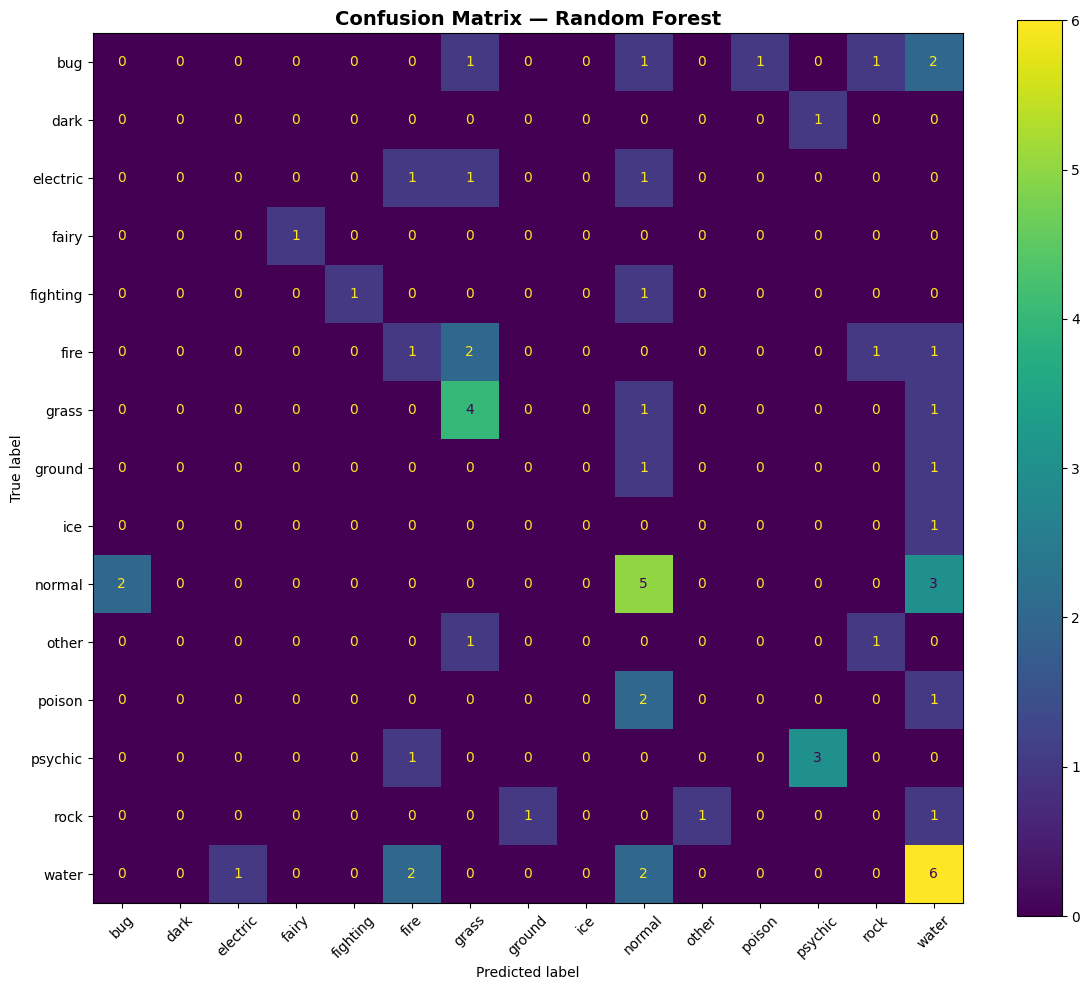

Confusion matrix plot saved.


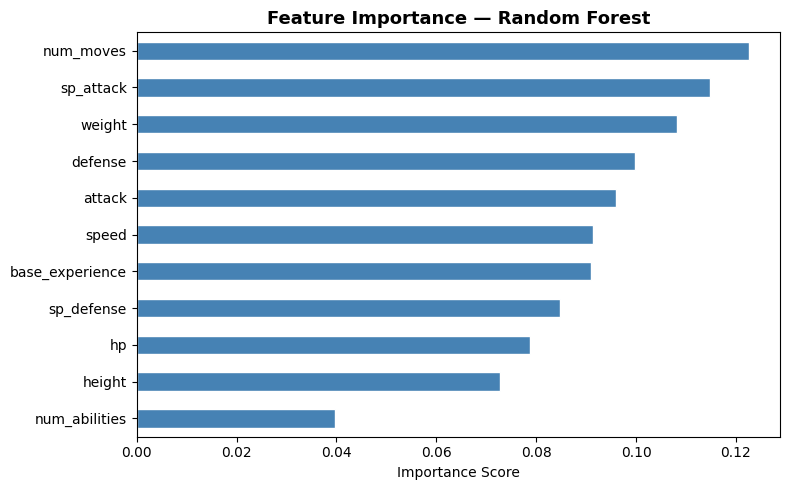

Feature importance plot saved.

All model artifacts (model.pkl, scaler.pkl, label_encoder.pkl, model_metrics.json) saved.


In [12]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("data/clean_data.csv")
print(f"Loaded {len(df)} rows from clean_data.csv")

FEATURES = [
    "hp", "attack", "defense", "sp_attack", "sp_defense",
    "speed", "height", "weight", "base_experience",
    "num_abilities", "num_moves",
]
TARGET = "primary_type"

X = df[FEATURES]
y = df[TARGET]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)
print(f"Training set: {len(X_train)} rows   Test set: {len(X_test)} rows")

# Scale numerical features
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

# Define and evaluate models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
}

print("\nModel Comparison:")
print("=================")

results    = {}
best_f1    = -1
best_name  = None
best_model = None
best_preds = None

for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc   = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="macro", zero_division=0
    )
    results[name] = {
        "accuracy":  round(float(acc),  4),
        "precision": round(float(prec), 4),
        "recall":    round(float(rec),  4),
        "f1":        round(float(f1),   4),
    }
    print(f"\n{name}")
    print(f"  Accuracy  : {acc:.3f}")
    print(f"  Precision : {prec:.3f}")
    print(f"  Recall    : {rec:.3f}")
    print(f"  F1 Score  : {f1:.3f}")

    if f1 > best_f1:
        best_f1, best_name, best_model, best_preds = f1, name, model, preds

print(f"\nBest performing model: {best_name} (macro F1 = {best_f1:.3f})")



# Plot confusion matrix for the best model
cm = confusion_matrix(y_test, best_preds, labels=range(len(le.classes_)))

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix plot saved.")


# Plot feature importance for the best model
if hasattr(best_model, "feature_importances_"):
    importances = dict(zip(FEATURES,
                           [round(float(v), 4) for v in best_model.feature_importances_]))
else:
    importances = dict(zip(FEATURES,
                           [round(float(abs(v)), 4) for v in best_model.coef_.mean(axis=0)])) # For linear models

fi_series = pd.Series(importances).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
fi_series.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title(f"Feature Importance — {best_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("data/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance plot saved.")


# Save all model artifacts
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler,     "scaler.pkl")
joblib.dump(le,         "label_encoder.pkl")

with open("model_metrics.json", "w") as f:
    json.dump({
        "all_model_results":  results,
        "best_model":         best_name,
        "confusion_matrix":   cm.tolist(),
        "class_labels":       le.classes_.tolist(),
        "feature_importance": importances,
        "features":           FEATURES,
    }, f, indent=2)

print("\nAll model artifacts (model.pkl, scaler.pkl, label_encoder.pkl, model_metrics.json) saved.")

In [1]:
!pip install streamlit pyngrok plotly -q

# Streamlit app code to app.py
app_code = '''
import json, joblib
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(page_title="Pokémon Type Classifier", page_icon="⚡", layout="wide")

TYPE_COLORS = {
    "fire":"#FF4500","water":"#1E90FF","grass":"#32CD32",
    "electric":"#FFD700","psychic":"#FF69B4","normal":"#A8A878",
    "rock":"#B8A038","ground":"#E0C068","poison":"#A040A0",
    "bug":"#A8B820","dragon":"#7038F8","ghost":"#705898",
    "ice":"#98D8D8","fighting":"#C03028","steel":"#B8B8D0","other":"#888888",
}

@st.cache_data
def load_data():
    raw   = pd.read_csv("data/raw_data.csv")
    clean = pd.read_csv("data/clean_data.csv")
    return raw, clean

@st.cache_resource
def load_artifacts():
    model   = joblib.load("model.pkl")
    scaler  = joblib.load("scaler.pkl")
    le      = joblib.load("label_encoder.pkl")
    with open("model_metrics.json") as f:
        metrics = json.load(f)
    return model, scaler, le, metrics

raw_df, clean_df           = load_data()
model, scaler, le, metrics = load_artifacts()
FEATURES = metrics["features"]

# ── Sidebar ──────────────────────────────────────────────────
st.sidebar.title("⚡ Navigation")
page = st.sidebar.radio("Go to", [
    "🏠 Home", "📊 Data Overview", "🔍 EDA",
    "🤖 Model Performance", "🎯 Live Prediction"
])
st.sidebar.markdown("---")
all_types = sorted(clean_df["primary_type"].unique())
selected  = st.sidebar.multiselect("Filter by type:", all_types, default=all_types)
filtered  = clean_df[clean_df["primary_type"].isin(selected)]
st.sidebar.caption("Data: PokéAPI (pokeapi.co)")

# ── HOME ─────────────────────────────────────────────────────
if page == "🏠 Home":
    st.title("⚡ Pokémon Type Classifier")
    st.markdown("""
    This dashboard predicts a Pokémon\'s **primary type** from its base stats
    using machine learning. Data comes from [PokéAPI](https://pokeapi.co) — completely free, no key needed.
    """)
    st.markdown("---")
    c1,c2,c3,c4 = st.columns(4)
    c1.metric("Total Pokémon (raw)",  len(raw_df))
    c2.metric("After cleaning",       len(clean_df))
    c3.metric("Types (classes)",      clean_df["primary_type"].nunique())
    c4.metric("Best model",           metrics["best_model"].split()[-1])
    st.markdown("---")
    st.subheader("Pipeline steps")
    c1,c2,c3,c4 = st.columns(4)
    c1.info("**1️⃣ Fetch**\\n\\nPull 300 Pokémon from PokéAPI, flatten nested JSON.")
    c2.info("**2️⃣ Clean**\\n\\nHandle missing values, duplicates, rare classes.")
    c3.info("**3️⃣ Train**\\n\\nCompare Logistic Regression vs Random Forest.")
    c4.info("**4️⃣ Predict**\\n\\nEnter stats in Live Prediction to classify.")

# ── DATA OVERVIEW ────────────────────────────────────────────
elif page == "📊 Data Overview":
    st.title("📊 Data Overview")
    tab1, tab2 = st.tabs(["Raw Data", "Clean Data"])
    with tab1:
        st.subheader(f"Raw — {len(raw_df)} rows × {raw_df.shape[1]} cols")
        c1,c2 = st.columns(2)
        c1.metric("Rows", len(raw_df))
        c2.metric("Missing values", int(raw_df.isnull().sum().sum()))
        st.dataframe(raw_df.head(20), use_container_width=True)
    with tab2:
        st.subheader(f"Clean — {len(clean_df)} rows × {clean_df.shape[1]} cols")
        c1,c2,c3 = st.columns(3)
        c1.metric("Rows", len(clean_df))
        c2.metric("Missing values", int(clean_df.isnull().sum().sum()))
        c3.metric("Types", clean_df["primary_type"].nunique())
        st.dataframe(clean_df.head(20), use_container_width=True)
    st.subheader("Descriptive statistics")
    st.dataframe(clean_df[FEATURES].describe().round(2), use_container_width=True)

# ── EDA ──────────────────────────────────────────────────────
elif page == "🔍 EDA":
    st.title("🔍 Exploratory Data Analysis")
    st.caption(f"Showing {len(filtered)} Pokémon — adjust sidebar filter to update charts.")
    if filtered.empty:
        st.warning("No Pokémon match your filter. Select at least one type.")
        st.stop()

    # Class balance
    st.subheader("1 — Class Balance")
    bal = filtered["primary_type"].value_counts().reset_index()
    bal.columns = ["Type","Count"]
    fig = px.bar(bal, x="Type", y="Count", color="Type",
                 color_discrete_map=TYPE_COLORS, text="Count",
                 title="Pokémon Count per Type")
    fig.update_traces(textposition="outside")
    fig.update_layout(showlegend=False, height=400)
    st.plotly_chart(fig, use_container_width=True)

    # Correlation heatmap
    st.subheader("2 — Correlation Heatmap")
    corr = filtered[FEATURES].corr().round(2)
    fig2 = go.Figure(go.Heatmap(z=corr.values, x=corr.columns.tolist(),
                                 y=corr.index.tolist(), colorscale="Blues",
                                 text=corr.values.round(2), texttemplate="%{text}",
                                 zmin=-1, zmax=1))
    fig2.update_layout(title="Feature Correlation Matrix", height=480)
    st.plotly_chart(fig2, use_container_width=True)

    # Boxplot
    st.subheader("3 — Feature by Type")
    feat = st.selectbox("Choose feature:", FEATURES, index=1)
    fig3 = px.box(filtered, x="primary_type", y=feat, color="primary_type",
                  color_discrete_map=TYPE_COLORS,
                  title=f"{feat.replace('_',' ').title()} by Type")
    fig3.update_layout(showlegend=False, height=420)
    st.plotly_chart(fig3, use_container_width=True)

    # Scatter
    st.subheader("4 — Scatter Plot")
    c1,c2 = st.columns(2)
    xf = c1.selectbox("X axis:", FEATURES, index=1)
    yf = c2.selectbox("Y axis:", FEATURES, index=2)
    fig4 = px.scatter(filtered, x=xf, y=yf, color="primary_type",
                      color_discrete_map=TYPE_COLORS, hover_name="name",
                      opacity=0.8, title=f"{xf} vs {yf}")
    fig4.update_layout(height=420)
    st.plotly_chart(fig4, use_container_width=True)

# ── MODEL PERFORMANCE ─────────────────────────────────────────
elif page == "🤖 Model Performance":
    st.title("🤖 Model Performance")
    rows = []
    for mname, mr in metrics["all_model_results"].items():
        rows.append({"Model": mname, "Accuracy": f"{mr['accuracy']:.3f}",
                     "Precision": f"{mr['precision']:.3f}",
                     "Recall": f"{mr['recall']:.3f}",
                     "F1 Score": f"{mr['f1']:.3f}",
                     "": "✅ Best" if mname==metrics["best_model"] else ""})
    st.dataframe(pd.DataFrame(rows), use_container_width=True, hide_index=True)
    st.info(f"**{metrics['best_model']}** selected by highest macro-F1.")
    st.markdown("---")

    # Confusion matrix
    st.subheader("Confusion Matrix")
    cm_arr = np.array(metrics["confusion_matrix"])
    labels = metrics["class_labels"]
    fig5 = px.imshow(cm_arr, x=labels, y=labels,
                     color_continuous_scale="Blues", text_auto=True,
                     labels=dict(x="Predicted", y="Actual"),
                     title=f"Confusion Matrix — {metrics['best_model']}")
    fig5.update_layout(height=580)
    st.plotly_chart(fig5, use_container_width=True)
    st.caption("Diagonal = correct predictions.")
    st.markdown("---")

    # Feature importance
    st.subheader("Feature Importance")
    fi = pd.DataFrame(list(metrics["feature_importance"].items()),
                      columns=["Feature","Importance"]).sort_values("Importance")
    fig6 = px.bar(fi, x="Importance", y="Feature", orientation="h",
                  color="Importance", color_continuous_scale="Blues",
                  title="Feature Importance")
    fig6.update_layout(height=400, coloraxis_showscale=False)
    st.plotly_chart(fig6, use_container_width=True)

# ── LIVE PREDICTION ───────────────────────────────────────────
elif page == "🎯 Live Prediction":
    st.title("🎯 Live Pokémon Type Prediction")
    st.markdown("Adjust the sliders and click **Predict** to classify a Pokémon.")
    c1, c2, c3 = st.columns(3)
    with c1:
        hp        = st.slider("HP",          1, 255, 65)
        attack    = st.slider("Attack",      1, 255, 75)
        defense   = st.slider("Defense",     1, 255, 70)
        sp_attack = st.slider("Sp. Attack",  1, 255, 70)
    with c2:
        sp_defense      = st.slider("Sp. Defense", 1, 255, 70)
        speed           = st.slider("Speed",       1, 255, 65)
        height          = st.slider("Height (dm)", 1, 100, 12)
        weight          = st.slider("Weight (hg)", 1, 2000, 600)
    with c3:
        base_experience = st.slider("Base Experience", 1, 400, 200)
        num_abilities   = st.selectbox("Num Abilities", [1,2,3], index=1)
        num_moves       = st.slider("Num Moves", 1, 120, 60)

    st.markdown("---")
    if st.button("⚡ Predict Type", use_container_width=True):
        inp = np.array([[hp, attack, defense, sp_attack, sp_defense,
                         speed, height, weight, base_experience,
                         num_abilities, num_moves]])
        inp_scaled   = scaler.transform(inp)
        pred_encoded = model.predict(inp_scaled)[0]
        pred_label   = le.inverse_transform([pred_encoded])[0]
        pred_color   = TYPE_COLORS.get(pred_label, "#888888")

        st.markdown(f"""
        <div style="background:{pred_color}22;border:2px solid {pred_color};
        border-radius:12px;padding:20px;text-align:center;margin:10px 0">
        <h2 style="color:{pred_color};margin:0">Predicted Type: {pred_label.upper()}</h2>
        </div>
        """, unsafe_allow_html=True)

        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(inp_scaled)[0]
            pdf = pd.DataFrame({"Type": le.classes_, "Probability": proba})
            pdf = pdf.sort_values("Probability", ascending=False).head(10)
            fig7 = px.bar(pdf, x="Type", y="Probability", color="Type",
                          color_discrete_map=TYPE_COLORS,
                          text=pdf["Probability"].apply(lambda p: f"{p:.1%}"),
                          title="Top 10 Type Probabilities")
            fig7.update_traces(textposition="outside")
            fig7.update_layout(showlegend=False, height=380,
                               yaxis=dict(tickformat=".0%"))
            st.plotly_chart(fig7, use_container_width=True)

        st.caption("Note: predicting type from stats alone is hard — many types share similar distributions.")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("Streamlit app (app.py) written to disk.")




Streamlit app (app.py) written to disk.


In [ ]:
import subprocess, threading, time

# 1. Clearing out old background tasks completely
!pkill streamlit
!pkill cloudflared

# 2. Downloading and properly install Cloudflared
print("Installing stable tunnel system...")
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# 3. Launching Streamlit
def run_streamlit():
    with open("logs.txt", "w") as log_file:
        subprocess.run([
            "streamlit", "run", "app.py",
            "--server.port=8501",
            "--server.headless=true",
            "--server.enableCORS=false",
            "--browser.gatherUsageStats=false"
        ], stdout=log_file, stderr=log_file)

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

print("\nWaiting 5 seconds for Streamlit...")
time.sleep(5)

# 4. Launching Cloudflare Tunnel
print("\nCreating your stable public link...")
print("⬇️ scroll down to the bottom of the logs to find the '.trycloudflare.com' link ⬇️\n")
!cloudflared tunnel --url http://localhost:8501

Installing stable tunnel system...
Selecting previously unselected package cloudflared.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.7.2) ...
Setting up cloudflared (2026.7.2) ...
Processing triggers for man-db (2.10.2-1) ...

Waiting 5 seconds for Streamlit...

Creating your stable public link...
⬇️ scroll down to the bottom of the logs to find the '.trycloudflare.com' link ⬇️

2026-07-17T13:14:19Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tun